In [122]:
# Importing libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [123]:
# Loading the dataset
df_raw = pd.read_excel("7F_FRONT_SIDE_AHU_REPORT-26.xlsx", sheet_name="7F_FRONT_SIDE_AHU_REPORT0", header=None)

headers        = df_raw.iloc[3].tolist()
df_raw         = df_raw.iloc[4:].reset_index(drop=True)
df_raw.columns = [str(c).strip() for c in headers]

print(df_raw.shape)
print(df_raw.columns.tolist())
df_raw.head(3)

(4177, 8)
['DateTime', 'Run Status.', 'Return Air Temperature', 'Set Point.Present', 'Supply Air Temp.', 'CHW Valve Command. (%)', 'S Run Hours.', 'Frequency. (Hz)']


,DateTime,Run Status.,Return Air Temperature,Set Point.Present,Supply Air Temp.,CHW Valve Command. (%),S Run Hours.,Frequency. (Hz)
0,2026-04-01 00:00:00,5,25.539999,5,25.279999,0,86,0
1,2026-04-01 00:10:00,5,25.59,5,25.32,0,86,0
2,2026-04-01 00:20:00,5,25.609999,5,25.24,0,86,0


In [124]:
# df_raw = pd.read_excel("7F_FRONT_SIDE_AHU_REPORT-26.xlsx", sheet_name="7F_FRONT_SIDE_AHU_REPORT0", header=None)

# # Print first 6 rows raw to see exact structure
# for i in range(6):
#     print(f"Row {i}: {df_raw.iloc[i].tolist()}")

In [125]:
# Check column names
df_raw.columns.tolist()
# Check data types

['DateTime',
 'Run Status.',
 'Return Air Temperature',
 'Set Point.Present',
 'Supply Air Temp.',
 'CHW Valve Command. (%)',
 'S Run Hours.',
 'Frequency. (Hz)']

In [126]:
# Preview the dataset
df_raw.head()

,DateTime,Run Status.,Return Air Temperature,Set Point.Present,Supply Air Temp.,CHW Valve Command. (%),S Run Hours.,Frequency. (Hz)
0,2026-04-01 00:00:00,5,25.539999,5,25.279999,0,86,0
1,2026-04-01 00:10:00,5,25.59,5,25.32,0,86,0
2,2026-04-01 00:20:00,5,25.609999,5,25.24,0,86,0
3,2026-04-01 00:30:00,5,25.639999,5,25.189999,0,86,0
4,2026-04-01 00:40:00,5,24.769999,5,25.309999,0,86,0


In [127]:
# Define constants for column names and rolling window size
# Configure variables
TIMESTAMP_COL = "DateTime"
TARGET_COL    = "Return Air Temperature"
SETPOINT_COL  = "Set Point.Present"
CHW_COL       = "CHW Valve Command. (%)"
SUPPLY_COL    = "Supply Air Temp."
ROLLING_WIN   = 6

In [128]:
# Filter only Running rows
df_running = df_raw[df_raw["Run Status."] == "RUNNING"].reset_index(drop=True)

print("Total rows        :", len(df_raw))
print("Running rows only :", len(df_running))
df_running.head(3)

Total rows        : 4177
Running rows only : 2151


,DateTime,Run Status.,Return Air Temperature,Set Point.Present,Supply Air Temp.,CHW Valve Command. (%),S Run Hours.,Frequency. (Hz)
0,2026-04-01 05:20:00,RUNNING,25.82,5,25.639999,0,86,30.029999
1,2026-04-01 05:30:00,RUNNING,25.82,5,25.68,0,86,30.029999
2,2026-04-01 05:40:00,RUNNING,25.809999,5,25.689999,0,86,30.029999


In [129]:
# Clean and parse — only Running rows
df = df_running[[TIMESTAMP_COL, TARGET_COL, SETPOINT_COL, CHW_COL, SUPPLY_COL]].copy()

df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], format="mixed", errors="coerce")
df[TARGET_COL]    = pd.to_numeric(df[TARGET_COL], errors="coerce")
df[SETPOINT_COL]  = pd.to_numeric(df[SETPOINT_COL], errors="coerce")
df[CHW_COL]       = pd.to_numeric(df[CHW_COL],    errors="coerce")
df[SUPPLY_COL]    = pd.to_numeric(df[SUPPLY_COL], errors="coerce")

df = df.dropna().sort_values(TIMESTAMP_COL).reset_index(drop=True)

print("Clean rows :", len(df))
print("Date range :", df[TIMESTAMP_COL].min(), "→", df[TIMESTAMP_COL].max())

Clean rows : 2151
Date range : 2026-04-01 05:20:00 → 2026-04-30 00:00:00


In [130]:
# Summary stats
df.describe()

,DateTime,Return Air Temperature,Set Point.Present,CHW Valve Command. (%),Supply Air Temp.
count,2151,2151.000000,2151.000000,2151.000000,2151.000000
mean,2026-04-14 20:33:23.626220,23.226173,15.906555,53.056826,17.191283
min,2026-04-01 05:20:00,21.039999,0.000000,0.000000,10.660000
25%,2026-04-08 06:45:00,22.590000,5.000000,36.246599,14.775000
50%,2026-04-15 03:40:00,23.010000,23.000000,49.367413,16.330000
75%,2026-04-22 00:35:00,23.680000,23.000000,73.902184,18.835000
max,2026-04-30 00:00:00,29.240000,24.000000,100.000000,26.549999
std,NaN,1.037795,9.530617,29.481184,3.789631


In [135]:
# Remove rows where setpoint is 0, 3 and 5
df = df[~df[SETPOINT_COL].isin([0, 3, 5])].reset_index(drop=True)

print("Rows after removing setpoint 0, 3 and 5 :", len(df))
print("\nSetpoint values remaining:")
print(df[SETPOINT_COL].value_counts().sort_index())

Rows after removing setpoint 0, 3 and 5 : 1390

Setpoint values remaining:
Set Point.Present
21       1
22     219
23    1113
24      57
Name: count, dtype: int64


In [136]:
# Pearson correlation — all 3 factors vs Return Air Temperature
factors = {
    "Set Point"       : SETPOINT_COL,
    "CHW Valve (%)"   : CHW_COL,
    "Supply Air Temp" : SUPPLY_COL
}

print("=" * 55)
print(f"  TARGET: {TARGET_COL}")
print("=" * 55)

results = {}
for name, col in factors.items():
    r, p = stats.pearsonr(df[col], df[TARGET_COL])
    results[name] = {"r": r, "p": p, "R2": r**2}
    sig = "*** significant" if p < 0.001 else "* significant" if p < 0.05 else "not significant"
    print(f"\n  [{name}]")
    print(f"  Pearson r : {r:.4f}")
    print(f"  R²        : {r**2:.4f}  ({100*r**2:.1f}% variance explained)")
    print(f"  p-value   : {p:.2e}  {sig}")

  TARGET: Return Air Temperature

  [Set Point]
  Pearson r : 0.3185
  R²        : 0.1014  (10.1% variance explained)
  p-value   : 3.85e-34  *** significant

  [CHW Valve (%)]
  Pearson r : 0.1288
  R²        : 0.0166  (1.7% variance explained)
  p-value   : 1.46e-06  *** significant

  [Supply Air Temp]
  Pearson r : 0.7686
  R²        : 0.5907  (59.1% variance explained)
  p-value   : 1.49e-271  *** significant


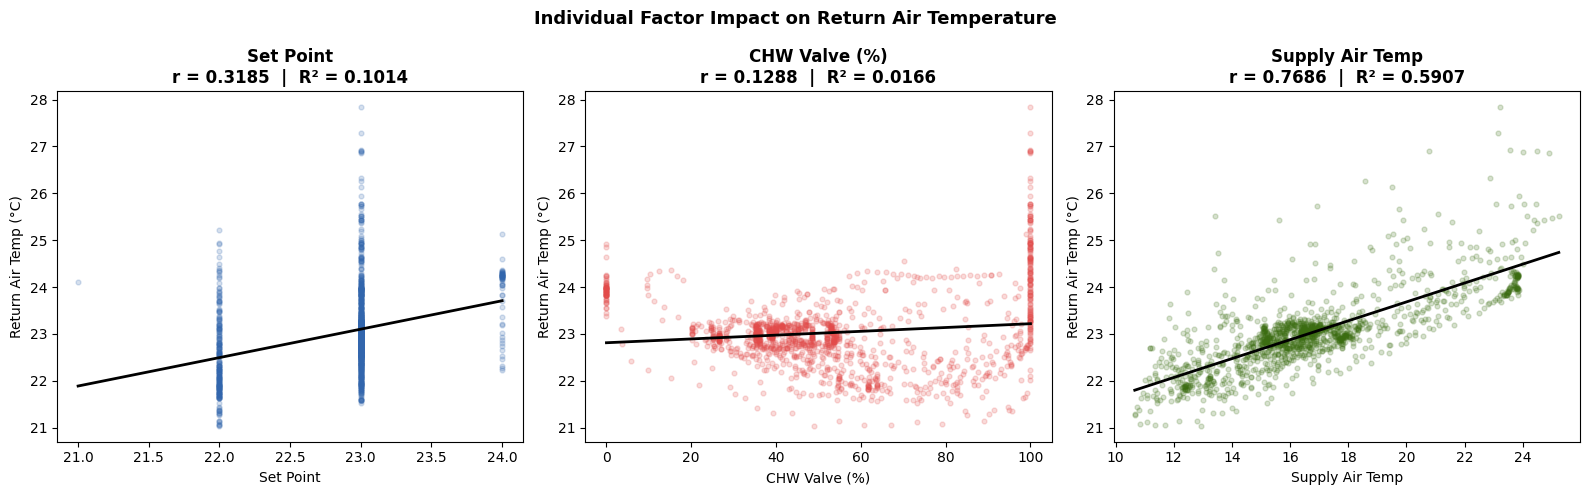

In [137]:
# Plot 1 - Scatter plots: each factor vs Return Air Temperature
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

factor_list = [
    ("Set Point",        SETPOINT_COL, "#3266ad"),
    ("CHW Valve (%)",    CHW_COL,      "#e24b4a"),
    ("Supply Air Temp",  SUPPLY_COL,   "#3b6d11"),
]

for ax, (name, col, color) in zip(axes, factor_list):
    r, _ = stats.pearsonr(df[col], df[TARGET_COL])
    reg  = stats.linregress(df[col], df[TARGET_COL])

    ax.scatter(df[col], df[TARGET_COL], alpha=0.2, s=12, color=color)
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(x_line, reg.slope * x_line + reg.intercept, color="black", linewidth=2)
    ax.set_xlabel(name)
    ax.set_ylabel("Return Air Temp (°C)")
    ax.set_title(f"{name}\nr = {r:.4f}  |  R² = {r**2:.4f}", fontweight="bold")

plt.suptitle("Individual Factor Impact on Return Air Temperature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Supply Air Temp is the #1 driver of Return Air Temp (59% impact)
# CHW Valve works indirectly — valve → supply air → return air
# Setpoint acts as a boundary (22, 23, 24°C), not a direct controller
# AHU is in good control — return air std only 1°C despite valve swinging 0–100%
# High temp scatter in supply air plot = peak load periods (afternoon/high occupancy)
# Pearson only captures direct relationships — CHW valve impact is underrated by r value

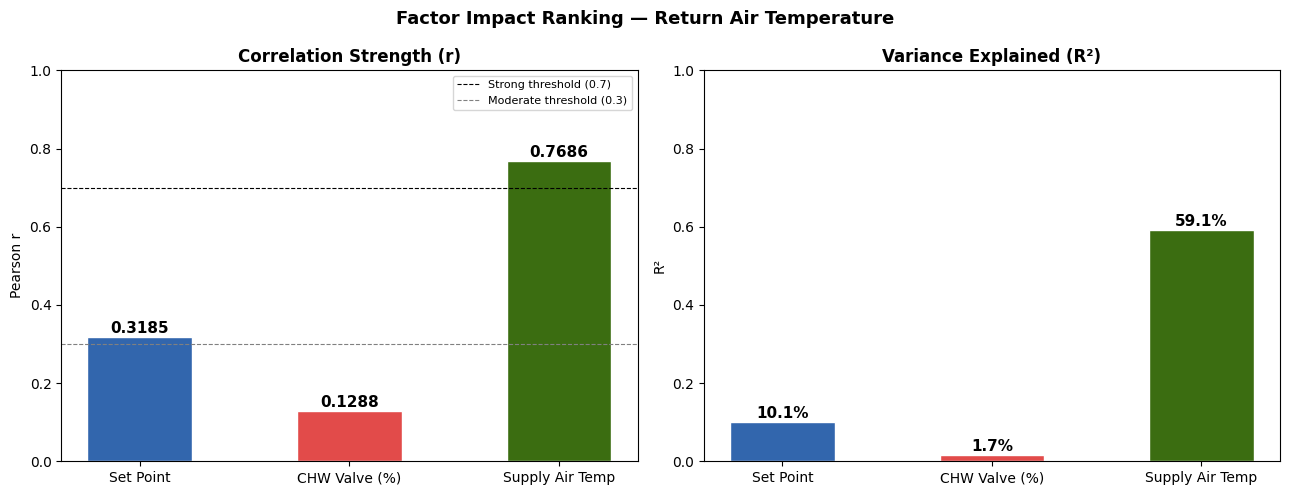

In [138]:
# Plot 2 - Ranked bar chart
names     = ["Set Point", "CHW Valve (%)", "Supply Air Temp"]
r_vals    = [results[n]["r"] for n in names]
r2_vals   = [results[n]["R2"] for n in names]
colors    = ["#3266ad", "#e24b4a", "#3b6d11"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pearson r
bars1 = ax1.bar(names, r_vals, color=colors, edgecolor="white", width=0.5)
ax1.set_ylabel("Pearson r")
ax1.set_title("Correlation Strength (r)", fontweight="bold")
ax1.set_ylim(0, 1)
ax1.axhline(0.7, color="black", linewidth=0.8, linestyle="--", label="Strong threshold (0.7)")
ax1.axhline(0.3, color="grey",  linewidth=0.8, linestyle="--", label="Moderate threshold (0.3)")
ax1.legend(fontsize=8)
for bar, val in zip(bars1, r_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

# R²
bars2 = ax2.bar(names, r2_vals, color=colors, edgecolor="white", width=0.5)
ax2.set_ylabel("R²")
ax2.set_title("Variance Explained (R²)", fontweight="bold")
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{100*val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Factor Impact Ranking — Return Air Temperature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

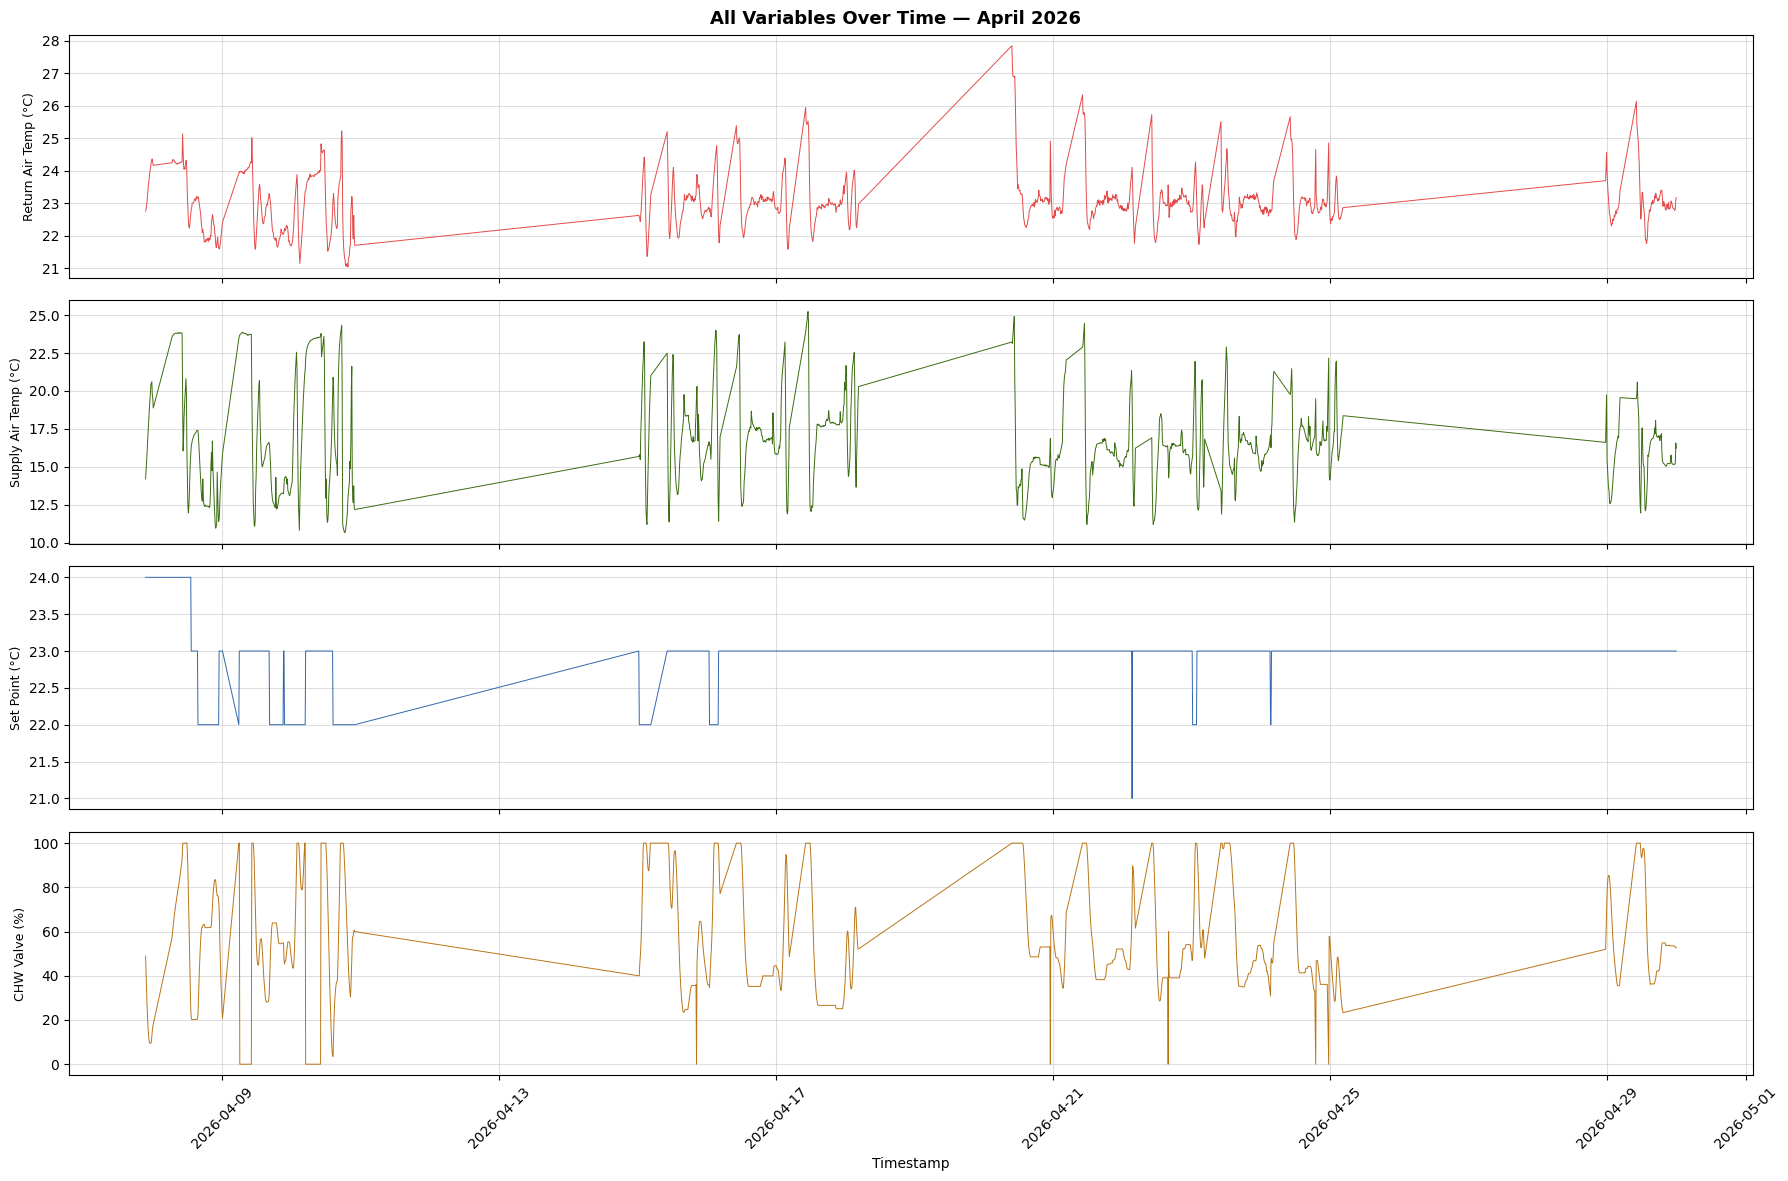

In [139]:
# Plot 3 - All variables over time
fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

plot_vars = [
    (TARGET_COL,   "Return Air Temp (°C)",  "#e24b4a"),
    (SUPPLY_COL,   "Supply Air Temp (°C)",  "#3b6d11"),
    (SETPOINT_COL, "Set Point (°C)",         "#3266ad"),
    (CHW_COL,      "CHW Valve (%)",          "#ba7517"),
]

for ax, (col, label, color) in zip(axes, plot_vars):
    ax.plot(df[TIMESTAMP_COL], df[col], color=color, linewidth=0.7)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Timestamp")
plt.suptitle("All Variables Over Time — April 2026", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# How the Chiller Plant Works — Control Logic

## Control Chain (Normal Behaviour)

Setpoint changes
↓
AHU controller sees Return Air is above/below target
↓
Commands CHW Valve to OPEN or CLOSE
↓
More/less chilled water flows through the coil
↓
Supply Air gets COOLER or WARMER
↓
Room temperature changes
↓
Return Air Temp moves toward Setpoint
↓
Controller sees target reached → CHW Valve adjusts back

---

## What Normal Looks Like
Return Air above Setpoint → Valve opens → Supply Air drops → Return Air comes down → Valve reduces back

This is a cause and effect chain with a time lag.

---

## Anomalies — When the Chain Breaks Down

**1. Valve Not Responding**
Return Air is above Setpoint BUT CHW Valve is not opening
→ Possible cause: controls fault, valve stuck

**2. Valve Open But Not Cooling**
CHW Valve is fully open BUT Supply Air Temp is not dropping
→ Possible cause: chiller not performing, low chilled water flow

**3. Overcooling**
CHW Valve open too long → Supply Air too cold
→ Return Air drops below Setpoint → energy waste

**4. Hunting**
CHW Valve rapidly oscillating up and down continuously
→ Possible cause: control instability, PID tuning issue

---

## Anomaly Detection Approach

**Core relationship to model:**
Expected Supply Air Temp = f(CHW Valve position)

- If actual Supply Air Temp is much higher than expected for a given valve position → Chiller is not performing → **ANOMALY**
- If CHW Valve is not responding to Return Air vs Setpoint gap → Controls issue → **ANOMALY**

---

## Detection Methods

| Method | What it does |
|---|---|
| **Rule Based** | Hard thresholds, simple and explainable |
| **Z-Score** | Flags statistically unusual values |
| **Isolation Forest** | ML model, finds unusual combinations of all factors together |

In [140]:
# ── PROOF 1: Gap period (Apr 9–17) is not real data ──────────
# If it's interpolated, the values will change by exactly the same amount every 10 min

df["supply_diff"] = df[SUPPLY_COL].diff()
df["return_diff"] = df[TARGET_COL].diff()
df["chw_diff"]    = df[CHW_COL].diff()

# Find the gap period
gap_mask = (df[TIMESTAMP_COL] >= "2026-04-09") & (df[TIMESTAMP_COL] <= "2026-04-17")
gap_data = df[gap_mask]

print("=== GAP PERIOD Apr 9–17 ===")
print(f"Rows in period          : {len(gap_data)}")
print(f"Unique Supply Air diffs : {gap_data['supply_diff'].nunique()}")
print(f"Unique CHW Valve diffs  : {gap_data['chw_diff'].nunique()}")
print(f"\nSupply Air diff stats:")
print(gap_data["supply_diff"].describe())

=== GAP PERIOD Apr 9–17 ===
Rows in period          : 464
Unique Supply Air diffs : 363
Unique CHW Valve diffs  : 273

Supply Air diff stats:
count    464.000000
mean       0.001034
std        1.264494
min       -8.370000
25%       -0.129999
50%        0.039999
75%        0.420000
max        7.599999
Name: supply_diff, dtype: float64


In [141]:
# ── PROOF 2: Setpoint change on Apr 21 ───────────────────────
# Find every time setpoint changed and what happened to other variables

df["setpoint_changed"] = df[SETPOINT_COL].diff().ne(0)
setpoint_changes = df[df["setpoint_changed"]][
    [TIMESTAMP_COL, SETPOINT_COL, TARGET_COL, SUPPLY_COL, CHW_COL]
]

print("=== ALL SETPOINT CHANGES ===")
print(setpoint_changes.to_string())

=== ALL SETPOINT CHANGES ===
                DateTime  Set Point.Present  Return Air Temperature  Supply Air Temp.  CHW Valve Command. (%)
0    2026-04-07 21:20:00                 24               22.750000         14.200000               48.927963
57   2026-04-08 13:10:00                 23               22.789999         16.340000               21.168118
71   2026-04-08 15:30:00                 22               23.170000         17.389999               22.281847
115  2026-04-08 22:50:00                 23               21.590000         11.520000               70.736588
123  2026-04-09 05:40:00                 22               23.920000         23.459999              100.000000
124  2026-04-09 05:50:00                 23               23.959999         23.619999              100.000000
187  2026-04-09 16:20:00                 22               23.230000         16.309999               36.973877
216  2026-04-09 21:10:00                 23               22.049999         13.219999      

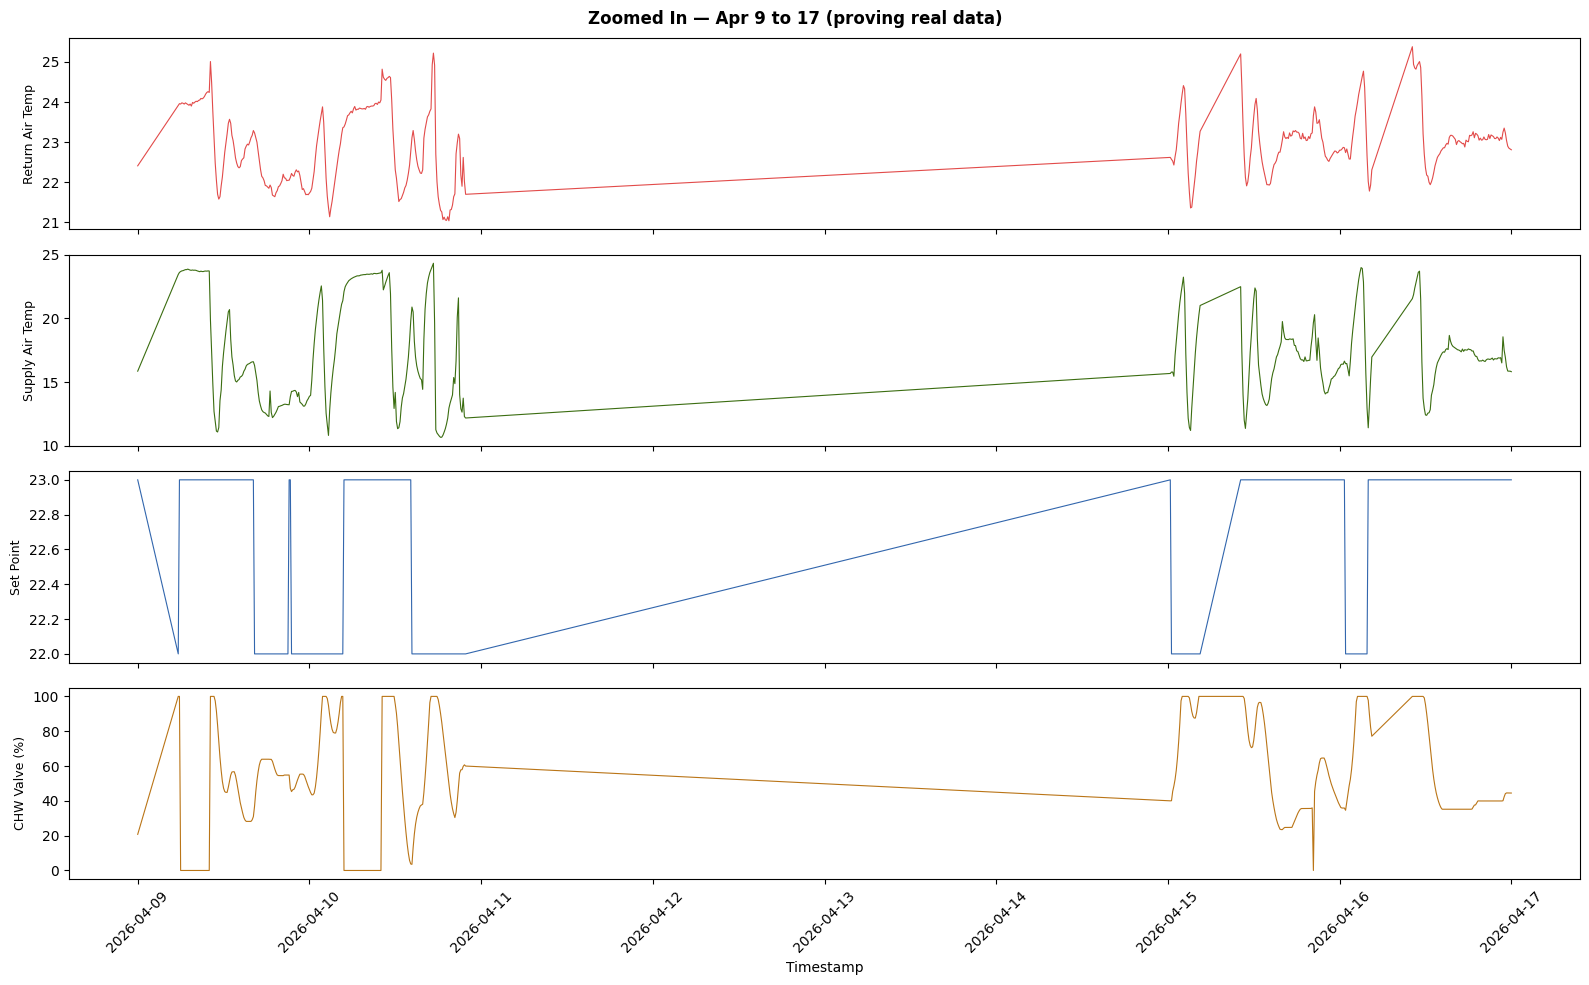

In [ ]:
# Confirm visually — zoom into gap period
gap = df[(df[TIMESTAMP_COL] >= "2026-04-09") & (df[TIMESTAMP_COL] <= "2026-04-17")]

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
for ax, (col, label, color) in zip(axes, [
    (TARGET_COL,   "Return Air Temp", "#e24b4a"),
    (SUPPLY_COL,   "Supply Air Temp", "#3b6d11"),
    (SETPOINT_COL, "Set Point",       "#3266ad"),
    (CHW_COL,      "CHW Valve (%)",   "#ba7517"),
]):
    ax.plot(gap[TIMESTAMP_COL], gap[col], color=color, linewidth=0.8)
    ax.set_ylabel(label, fontsize=9)

axes[-1].set_xlabel("Timestamp")
plt.suptitle("Zoomed In — Apr 9 to 17", fontweight="bold")  # proving real data
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

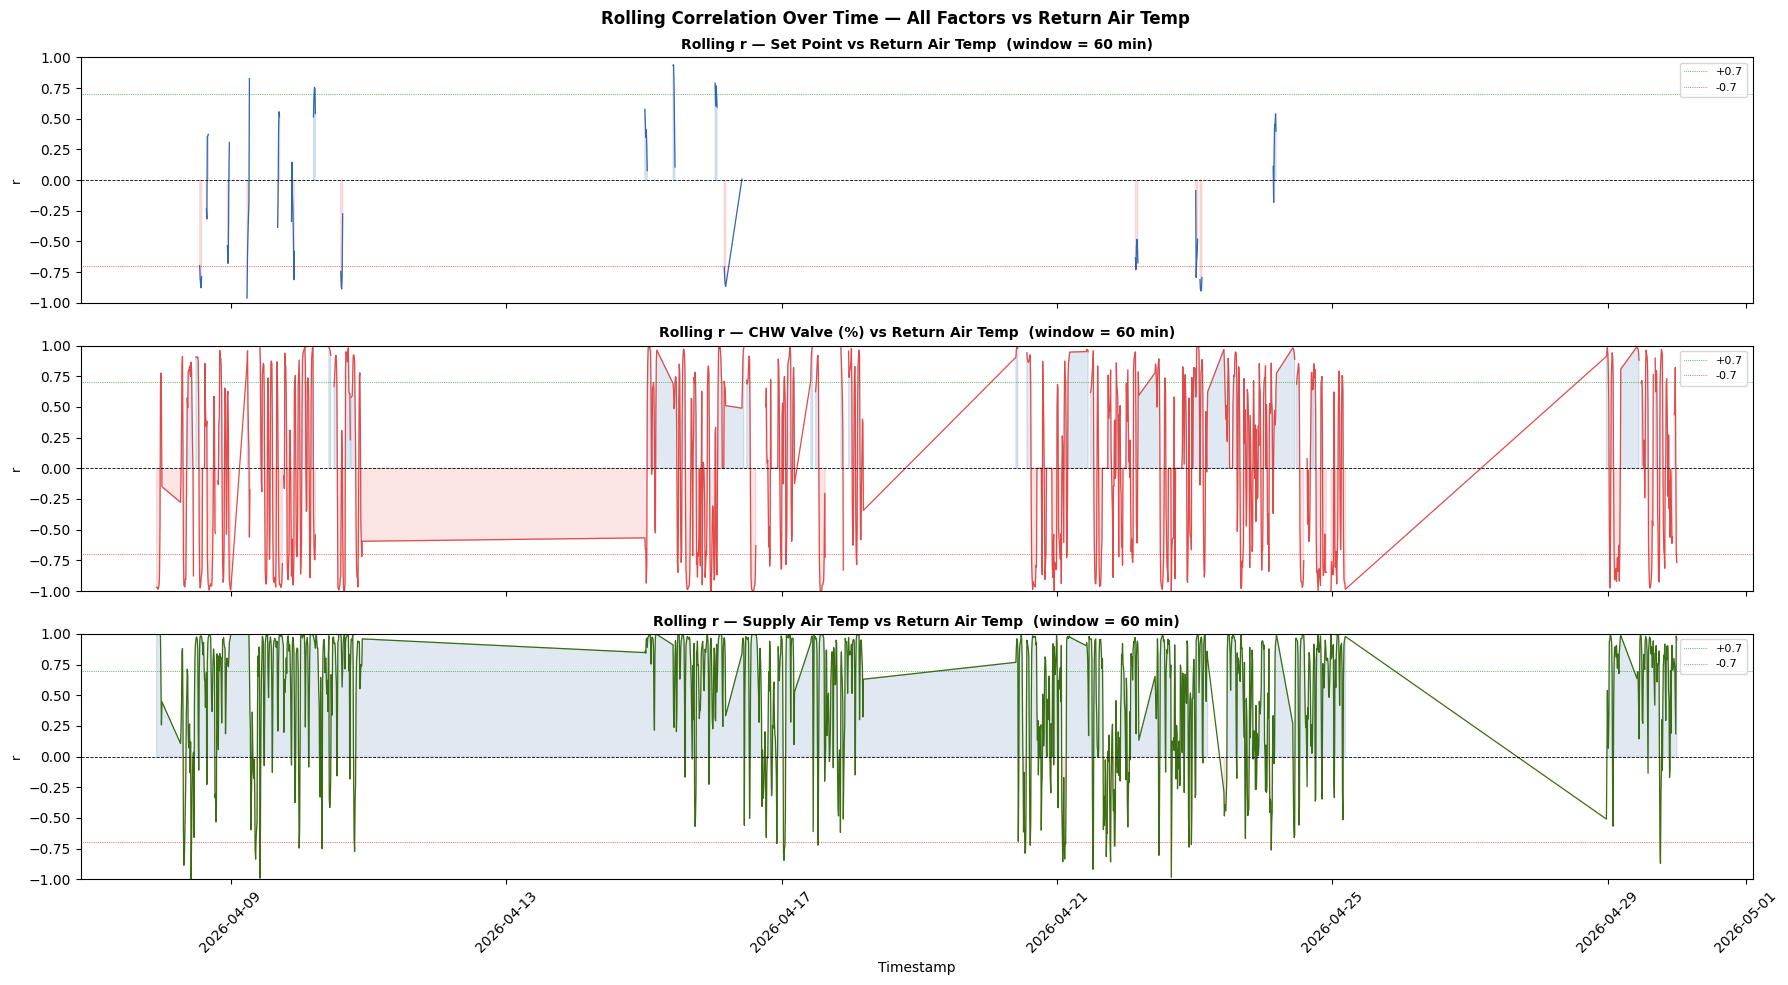

In [143]:
# Plot 4 - Rolling correlation over time
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

roll_factors = [
    ("Set Point",       SETPOINT_COL, "#3266ad"),
    ("CHW Valve (%)",   CHW_COL,      "#e24b4a"),
    ("Supply Air Temp", SUPPLY_COL,   "#3b6d11"),
]

for ax, (name, col, color) in zip(axes, roll_factors):
    rolling_r = df[TARGET_COL].rolling(ROLLING_WIN).corr(df[col])
    ax.plot(df[TIMESTAMP_COL], rolling_r, color=color, linewidth=0.9)
    ax.axhline( 0,   color="black", linewidth=0.6, linestyle="--")
    ax.axhline( 0.7, color="green", linewidth=0.5, linestyle=":", label="+0.7")
    ax.axhline(-0.7, color="red",   linewidth=0.5, linestyle=":", label="-0.7")
    ax.fill_between(df[TIMESTAMP_COL], rolling_r, 0,
                    where=rolling_r > 0, alpha=0.15, color="#3266ad")
    ax.fill_between(df[TIMESTAMP_COL], rolling_r, 0,
                    where=rolling_r < 0, alpha=0.15, color="#e24b4a")
    ax.set_ylim(-1, 1)
    ax.set_ylabel("r", fontsize=9)
    ax.set_title(f"Rolling r — {name} vs Return Air Temp  (window = {ROLLING_WIN * 10} min)", 
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Timestamp")
plt.suptitle("Rolling Correlation Over Time — All Factors vs Return Air Temp",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [144]:
# Prove hunting is breaking the correlations
# Count how many times rolling r crosses zero per variable

print("=== CORRELATION INSTABILITY PROOF ===")
for col, name in [(SETPOINT_COL, "Set Point"), 
                  (CHW_COL,      "CHW Valve"),
                  (SUPPLY_COL,   "Supply Air")]:
    rolling_r = df[TARGET_COL].rolling(ROLLING_WIN).corr(df[col]).dropna()
    zero_crossings = (rolling_r.shift(1) * rolling_r < 0).sum()
    time_above_07  = (rolling_r > 0.7).mean() * 100
    time_below_neg07 = (rolling_r < -0.7).mean() * 100
    print(f"\n  [{name}]")
    print(f"  Zero crossings (unstable) : {zero_crossings}")
    print(f"  Time above +0.7 (strong)  : {time_above_07:.1f}%")
    print(f"  Time below -0.7 (inverse) : {time_below_neg07:.1f}%")

=== CORRELATION INSTABILITY PROOF ===

  [Set Point]
  Zero crossings (unstable) : 292
  Time above +0.7 (strong)  : 43.9%
  Time below -0.7 (inverse) : 46.9%

  [CHW Valve]
  Zero crossings (unstable) : 238
  Time above +0.7 (strong)  : 26.0%
  Time below -0.7 (inverse) : 25.2%

  [Supply Air]
  Zero crossings (unstable) : 206
  Time above +0.7 (strong)  : 53.8%
  Time below -0.7 (inverse) : 2.6%


In [146]:
# Find the right thresholds from data
print("=== THRESHOLD ANALYSIS ===")

# Gap between Return Air and Setpoint
df["temp_gap"] = df[TARGET_COL] - df[SETPOINT_COL]
print("\nReturn Air vs Setpoint gap:")
print(df["temp_gap"].describe())

# Supply Air when valve is above 85%
high_valve = df[df[CHW_COL] > 85]
print(f"\nSupply Air Temp. > 85%:")
print(high_valve[SUPPLY_COL].describe())

# Valve direction reversals per hour
df["valve_dir"]     = np.sign(df[CHW_COL].diff())
df["dir_reversal"]  = (df["valve_dir"].diff().ne(0)) & (df["valve_dir"].ne(0))
reversals_per_hour = df.groupby(
    df[TIMESTAMP_COL].dt.floor("h")
)["dir_reversal"].sum()

print(f"\nValve reversals per hour:")
print(reversals_per_hour.describe())
print(f"\nHours with more than 4 reversals: {(reversals_per_hour > 4).sum()}")

=== THRESHOLD ANALYSIS ===

Return Air vs Setpoint gap:
count    1390.000000
mean        0.147956
std         0.800441
min        -1.770000
25%        -0.250000
50%         0.029999
75%         0.309999
max         4.840000
Name: temp_gap, dtype: float64

Supply Air Temp. > 85%:
count    248.000000
mean      17.225604
std        4.493248
min       10.660000
25%       13.159999
50%       16.425000
75%       21.577499
max       25.240000
Name: Supply Air Temp., dtype: float64

Valve reversals per hour:
count    243.000000
mean       0.646091
std        0.748452
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: dir_reversal, dtype: float64

Hours with more than 4 reversals: 0


In [147]:
# The hunting we saw visually might be large swings not frequent reversals
# Check valve swing size instead

df["valve_swing"] = df[CHW_COL].diff().abs()

print("=== VALVE SWING ANALYSIS ===")
print(df["valve_swing"].describe())
print(f"\nSwings > 20% in one step  : {(df['valve_swing'] > 20).sum()} rows")
print(f"Swings > 50% in one step  : {(df['valve_swing'] > 50).sum()} rows")
print(f"Swings > 80% in one step  : {(df['valve_swing'] > 80).sum()} rows")

# Also check sustained high gap periods
print("\n=== SUSTAINED HIGH GAP (>1.5°C for 3+ consecutive rows) ===")
df["anomaly_gap"] = df["temp_gap"] > 1.5
df["gap_sustained"] = (
    df["anomaly_gap"] & 
    df["anomaly_gap"].shift(1) & 
    df["anomaly_gap"].shift(2)
)
print(f"Sustained gap anomaly rows : {df['gap_sustained'].sum()}")
print(f"\nWhen did they occur:")
print(df[df["gap_sustained"]][[TIMESTAMP_COL, TARGET_COL, SETPOINT_COL, "temp_gap", CHW_COL, SUPPLY_COL]].to_string())

=== VALVE SWING ANALYSIS ===
count    1389.000000
mean        2.890045
std         8.165286
min         0.000000
25%         0.000000
50%         0.735464
75%         3.081511
max       100.000000
Name: valve_swing, dtype: float64

Swings > 20% in one step  : 25 rows
Swings > 50% in one step  : 12 rows
Swings > 80% in one step  : 4 rows

=== SUSTAINED HIGH GAP (>1.5°C for 3+ consecutive rows) ===
Sustained gap anomaly rows : 58

When did they occur:
                DateTime  Return Air Temperature  Set Point.Present  temp_gap  CHW Valve Command. (%)  Supply Air Temp.
244  2026-04-10 01:50:00               23.879999                 22  1.879999              100.000000         21.439999
296  2026-04-10 10:30:00               24.570000                 23  1.570000              100.000000         22.529999
297  2026-04-10 10:40:00               24.539999                 23  1.539999              100.000000         22.840000
298  2026-04-10 10:50:00               24.590000                 2

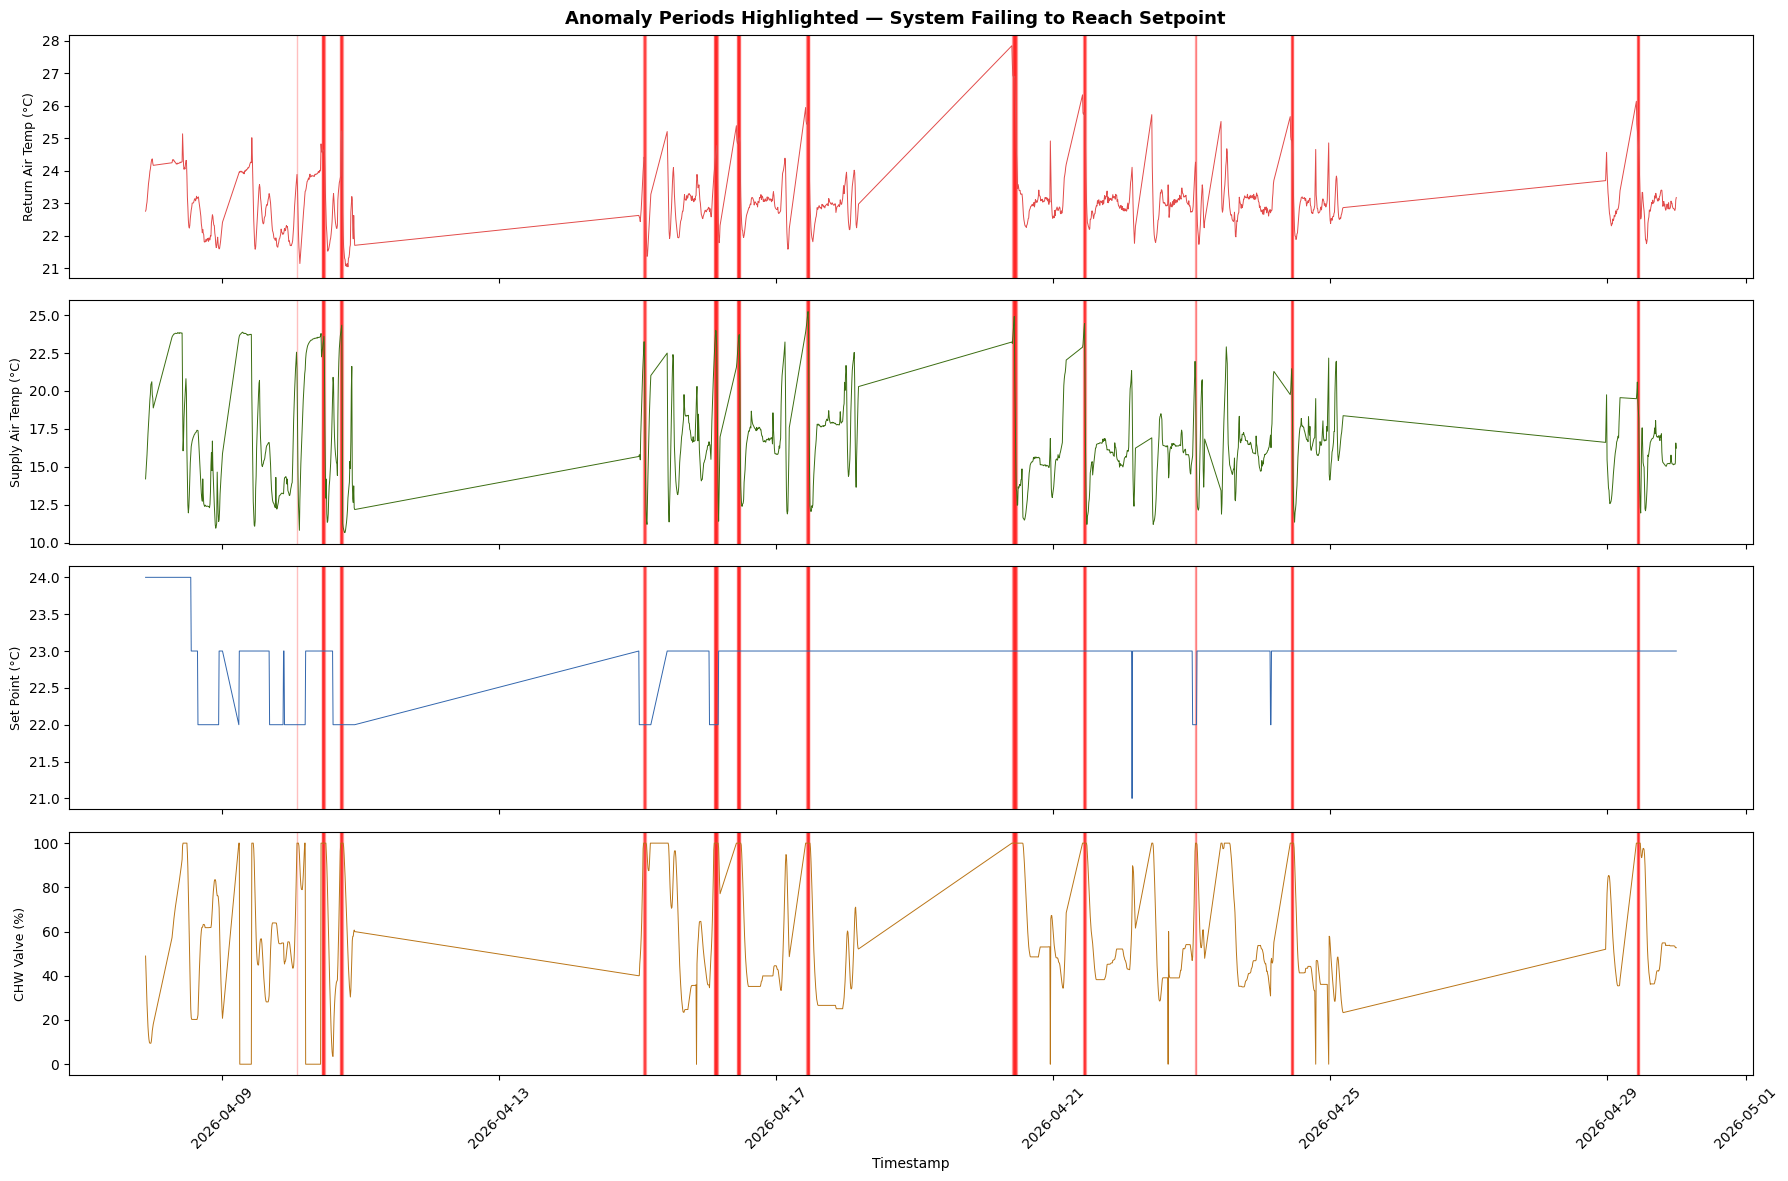

In [148]:
# Graph 1 — Highlight anomaly periods on time series
fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

anomaly_times = df[df["gap_sustained"]][TIMESTAMP_COL]

for ax, (col, label, color) in zip(axes, [
    (TARGET_COL,   "Return Air Temp (°C)", "#e24b4a"),
    (SUPPLY_COL,   "Supply Air Temp (°C)", "#3b6d11"),
    (SETPOINT_COL, "Set Point (°C)",        "#3266ad"),
    (CHW_COL,      "CHW Valve (%)",         "#ba7517"),
]):
    ax.plot(df[TIMESTAMP_COL], df[col], color=color, linewidth=0.7, zorder=2)
    # Highlight anomaly periods in red
    for t in anomaly_times:
        ax.axvspan(t - pd.Timedelta(minutes=10), 
                   t + pd.Timedelta(minutes=10),
                   alpha=0.25, color="red", zorder=1)
    ax.set_ylabel(label, fontsize=9)

axes[-1].set_xlabel("Timestamp")
plt.suptitle("Anomaly Periods Highlighted — System Failing to Reach Setpoint",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Anomaly Periods on Time Series
Red bands mark moments where Return Air exceeded Setpoint by more than 1.5°C for 30+ minutes.
Every red band shows CHW Valve at 100% — system is trying but failing to cool the space.


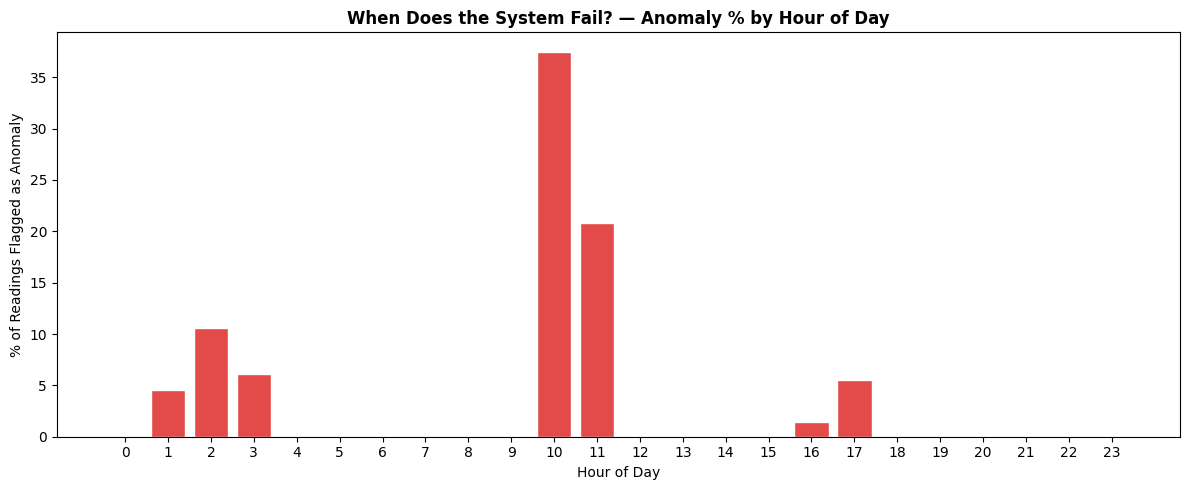

In [149]:
# Graph 2 — Time of day pattern: when do anomalies happen?
df["hour"] = df[TIMESTAMP_COL].dt.hour

anomaly_by_hour    = df[df["gap_sustained"]].groupby("hour").size()
total_by_hour      = df.groupby("hour").size()
anomaly_pct_by_hour = (anomaly_by_hour / total_by_hour * 100).fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(anomaly_pct_by_hour.index, anomaly_pct_by_hour.values,
       color="#e24b4a", edgecolor="white")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("% of Readings Flagged as Anomaly")
ax.set_title("When Does the System Fail? — Anomaly % by Hour of Day",
             fontweight="bold")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## When Does the System Fail?
37% of all 10:00 AM readings and 21% of 11:00 AM readings are flagged as anomalies.
Failures are concentrated at morning peak load — not a random fault, a recurring capacity problem.

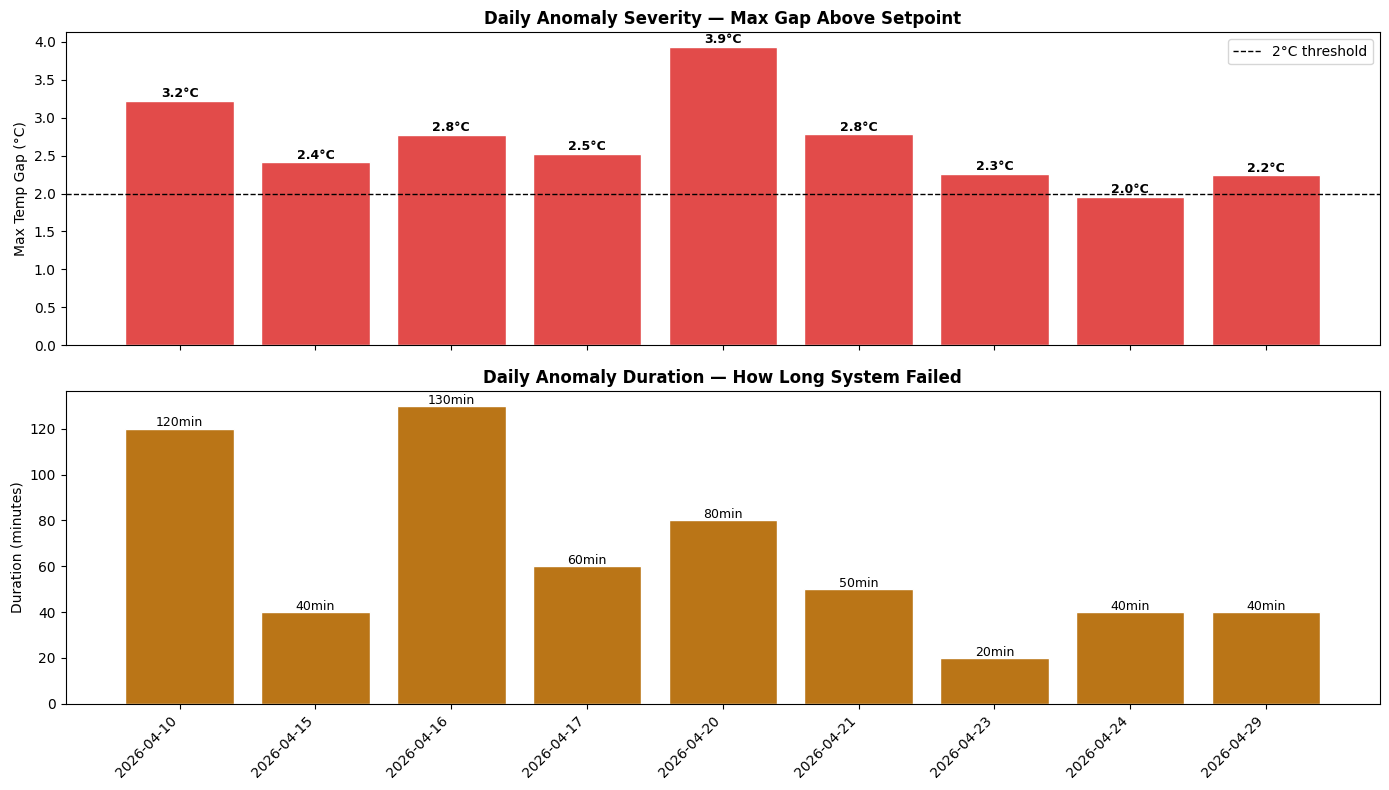

In [150]:
# Graph 3 — Anomaly severity: how bad was the gap on each date?
df["date"] = df[TIMESTAMP_COL].dt.date

daily_max_gap  = df[df["gap_sustained"]].groupby("date")["temp_gap"].max()
daily_duration = df[df["gap_sustained"]].groupby("date").size() * 10  # in minutes

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.bar(range(len(daily_max_gap)), daily_max_gap.values,
        color="#e24b4a", edgecolor="white")
ax1.set_ylabel("Max Temp Gap (°C)")
ax1.set_title("Daily Anomaly Severity — Max Gap Above Setpoint", fontweight="bold")
ax1.axhline(2.0, color="black", linestyle="--", linewidth=1, label="2°C threshold")
ax1.legend()
for i, (date, val) in enumerate(daily_max_gap.items()):
    ax1.text(i, val + 0.05, f"{val:.1f}°C", ha="center", fontsize=9, fontweight="bold")

ax2.bar(range(len(daily_duration)), daily_duration.values,
        color="#ba7517", edgecolor="white")
ax2.set_ylabel("Duration (minutes)")
ax2.set_title("Daily Anomaly Duration — How Long System Failed", fontweight="bold")
ax2.set_xticks(range(len(daily_max_gap)))
ax2.set_xticklabels([str(d) for d in daily_max_gap.index], rotation=45, ha="right")
for i, (date, val) in enumerate(daily_duration.items()):
    ax2.text(i, val + 1, f"{val}min", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Daily Anomaly Severity and Duration
Apr 20 was the worst day with a 3.9°C gap above setpoint lasting 80 minutes.
Every affected day exceeded the 2°C threshold — this is a recurring daily pattern not a one-off.

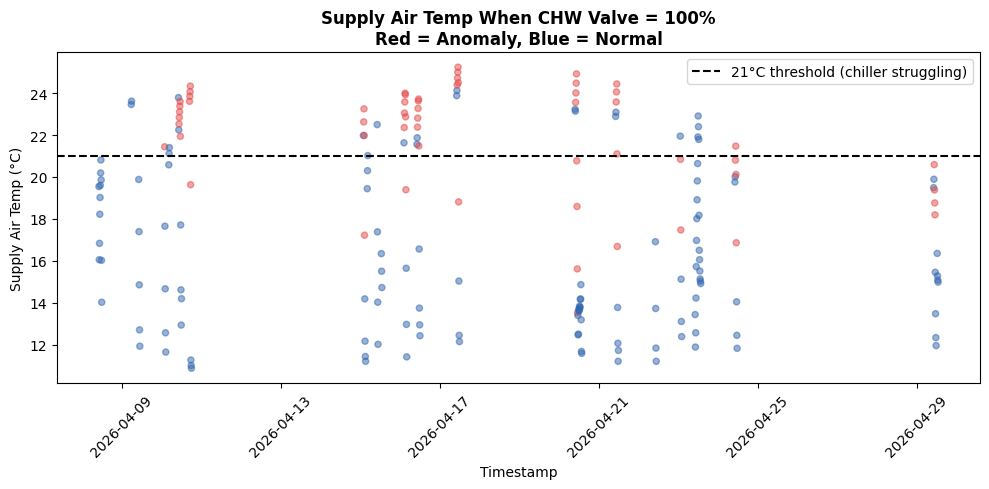

In [ ]:
# Graph 4 — Supply Air Temp when valve is 100%: proving chiller capacity issue
at_100 = df[df[CHW_COL] > 95].copy()
at_100["is_anomaly"] = at_100["gap_sustained"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(at_100[TIMESTAMP_COL], at_100[SUPPLY_COL],
           c=at_100["is_anomaly"].map({True: "#e24b4a", False: "#3266ad"}),
           alpha=0.5, s=20)
ax.axhline(21, color="black", linestyle="--", linewidth=1.5,
           label="21°C threshold (chiller struggling)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Supply Air Temp (°C)")
ax.set_title("Supply Air Temp When CHW Valve = 100%\nRed = Anomaly, Blue = Normal",
             fontweight="bold")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Supply Air Temp When CHW Valve = 100%
When the valve is fully open, supply air should be at its coldest — red dots above 21°C prove it is not.
Chiller is losing capacity exactly when peak load demands it most.

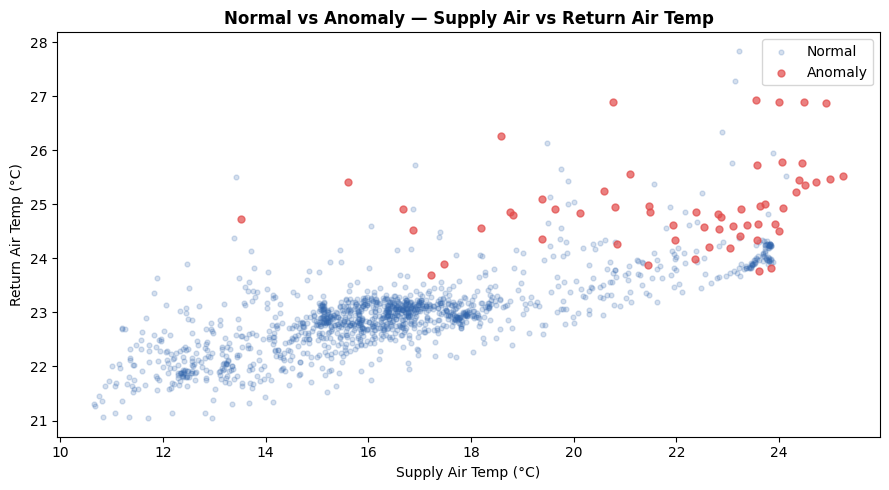

In [ ]:
# Graph 5 — Scatter: prove valve 100% + high supply air = anomaly
fig, ax = plt.subplots(figsize=(9, 5))

normal   = df[~df["gap_sustained"]]
anomaly  = df[df["gap_sustained"]]

ax.scatter(normal[SUPPLY_COL],  normal[TARGET_COL],
           alpha=0.2, s=12, color="#3266ad", label="Normal")
ax.scatter(anomaly[SUPPLY_COL], anomaly[TARGET_COL],
           alpha=0.7, s=25, color="#e24b4a", label="Anomaly", zorder=3)

ax.set_xlabel("Supply Air Temp (°C)")
ax.set_ylabel("Return Air Temp (°C)")
ax.set_title("Normal vs Anomaly — Supply Air vs Return Air Temp",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Normal vs Anomaly: Supply Air vs Return Air
Normal operation clusters tightly in the lower diagonal — controlled and stable.
Anomalies sit in the top right corner — high supply air and high return air, fingerprint of chiller capacity shortfall.

## Final Conclusion | April 2026

- System is **well controlled 95% of the time** — average deviation from setpoint is only 0.15°C
- **Supply Air Temperature** is the real driver of Return Air Temp — not the valve, not the setpoint
- System **fails every day between 10:00–11:30 AM** without exception — not random, fully predictable
- During every failure — **valve is at 100% but supply air is still warm** — controls are not the problem
- **Chiller cannot meet peak morning load** — worst day Apr 20 was 3.9°C above setpoint for 80 minutes